# ANN for Image Classification with MNIST

## 1. Import libraries

In [36]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

## 2. Load the MNIST dataset

In [37]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print('Training samples:', len(train_dataset))
print('Test samples:', len(test_dataset))

Training samples: 60000
Test samples: 10000


## 3. Inspect one sample

Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])
First label: 0


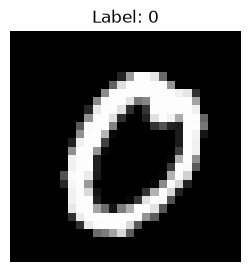

In [ ]:
# import matplotlib.pyplot as plt

# images, labels = next(iter(train_loader))
# print('Image batch shape:', images.shape)
# print('Label batch shape:', labels.shape)
# print('First label:', labels[0].item())

# first_image = images[0][0]
# plt.figure(figsize=(3, 3))
# plt.imshow(first_image, cmap='gray')
# plt.title(f'Label: {labels[0].item()}')
# plt.axis('off')
# plt.show()

## 4. Define the neural network

In [61]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=28 * 28, out_features=128), # nn.Linear(784, 128)
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=64),
    nn.ReLU(),
    nn.Linear(in_features=64, out_features=10)
)

print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=64, bias=True)
  (4): ReLU()
  (5): Linear(in_features=64, out_features=10, bias=True)
)


## 5. Define loss function and optimizer

In [62]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## 6. Train the model

In [63]:
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f'Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}')

Epoch 1/5, Loss: 0.3554
Epoch 2/5, Loss: 0.1491
Epoch 3/5, Loss: 0.1007
Epoch 4/5, Loss: 0.0764
Epoch 5/5, Loss: 0.0594


## 7. Evaluate on the test set

In [64]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy: {accuracy:.2f}%')

Accuracy: 97.39%
